# TensorFlow Deep Neural Network (MLP)
Two hidden layers capture higher-order relationships among early-game stats.

## Why this architecture?
- Adds non-linear capacity beyond the random forest while remaining lightweight enough for 10k samples.
- Dropout + L2 guard against memorizing rare match scenarios.
- Adam optimizer with moderate learning rate converges quickly on standardized features.

### Hyperparameters to justify/tune
| Hyperparameter | Reasoning | Suggested values |
| --- | --- | --- |
| Hidden units per layer | Wider layers capture more interactions; too wide risks overfitting. | `[128, 64]`, `[64, 32]` |
| Dropout rate | Regularizes against correlated inputs (gold & XP). | 0.2 – 0.4 |
| L2 penalty | Encourages smaller weights for stability. | `5e-5` – `1e-3` |
| Learning rate | Controls convergence speed. | `5e-4`, `1e-3`, `2e-3` |
| Batch size | Impacts gradient noise. | 32, 64, 128 |
| EarlyStopping patience | Avoids under/over-training. | 10 – 20 |


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'src').exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError('Could not find project root containing src/')
    REPO_ROOT = REPO_ROOT.parent

print(f'Using repo root: {REPO_ROOT}')
DATA_PATH = REPO_ROOT / 'data/raw/high_diamond_ranked_10min.csv'
RAW = pd.read_csv(DATA_PATH)
TARGET = 'blueWins'
FEATURES = [col for col in RAW.columns if col not in {TARGET, 'gameId'}]

X_train, X_test, y_train, y_test = train_test_split(
    RAW[FEATURES], RAW[TARGET], test_size=0.2, stratify=RAW[TARGET], random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
input_dim = X_train_scaled.shape[1]


Using repo root: /Users/liamsandy/ML_Project


### Load engineered features (reuse across models)

In [20]:
import pandas as pd

def safe_ratio(numerator, denominator, fill_value=0.0):
    denominator = denominator.replace(0, pd.NA)
    return (numerator / denominator).fillna(fill_value)

def engineer_features_inline(df):
    features = df.copy()
    blue_obj = features['blueDragons'] + features['blueHeralds'] + features['blueEliteMonsters']
    red_obj = features['redDragons'] + features['redHeralds'] + features['redEliteMonsters']
    total_obj = blue_obj + red_obj
    features['blue_objective_share'] = safe_ratio(blue_obj, total_obj, 0.5)
    features['red_objective_share'] = safe_ratio(red_obj, total_obj, 0.5)
    total_wards = features['blueWardsPlaced'] + features['redWardsPlaced']
    features['blue_vision_share'] = safe_ratio(features['blueWardsPlaced'], total_wards, 0.5)
    features['red_vision_share'] = safe_ratio(features['redWardsPlaced'], total_wards, 0.5)
    features['blue_ward_efficiency'] = safe_ratio(features['blueWardsDestroyed'], features['blueWardsPlaced'], 0.0)
    features['red_ward_efficiency'] = safe_ratio(features['redWardsDestroyed'], features['redWardsPlaced'], 0.0)
    total_kills = features['blueKills'] + features['redKills']
    features['blue_kill_share'] = safe_ratio(features['blueKills'], total_kills, 0.5)
    features['red_kill_share'] = safe_ratio(features['redKills'], total_kills, 0.5)
    features['blue_gold_per_kill'] = safe_ratio(features['blueTotalGold'], features['blueKills'] + 1)
    features['red_gold_per_kill'] = safe_ratio(features['redTotalGold'], features['redKills'] + 1)
    features['blue_xp_per_min'] = features['blueTotalExperience'] / 10.0
    features['red_xp_per_min'] = features['redTotalExperience'] / 10.0
    features['gold_obj_momentum'] = features['blueGoldDiff'] * (features['blueDragons'] + features['blueHeralds'])
    features['xp_kill_momentum'] = features['blueExperienceDiff'] * features['blueKills']
    features['gold_diff_per_min'] = features['blueGoldDiff'] / 10.0
    features['xp_diff_per_min'] = features['blueExperienceDiff'] / 10.0
    if 'gameId' in features:
        features = features.drop(columns=['gameId'])
    return features

engineered_csv = (REPO_ROOT / 'data/processed/engineered_features.csv').resolve()
if engineered_csv.exists():
    engineered_df = pd.read_csv(engineered_csv)
    print('Loaded engineered CSV:', engineered_df.shape)
else:
    print('Engineered CSV missing; computing inline.')
    engineered_df = engineer_features_inline(RAW)
    print('Inline engineered shape:', engineered_df.shape)


Loaded engineered CSV: (9879, 55)


In [22]:
from pathlib import Path
import pandas as pd

ENGINEERED_PATH = (REPO_ROOT / 'data/processed/engineered_features.csv').resolve()
if ENGINEERED_PATH.exists():
    engineered_df = pd.read_csv(ENGINEERED_PATH)
else:
    print('Engineered CSV not found; falling back to on-the-fly features.')
    from feature_engineering_playbook import engineer_features  # adjust if needed
    engineered_df = engineer_features(BASE_DF)
print('Engineered shape:', engineered_df.shape)


Engineered shape: (9879, 55)


In [11]:
def build_mlp(
    input_dim: int,
    hidden_units=(128, 64),
    dropout_rate: float = 0.4,
    l2: float = 5e-5,
    learning_rate: float = 5e-4,
):
    model = tf.keras.Sequential(name='mlp_classifier')
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(tf.keras.layers.Dense(
            units,
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(l2),
        ))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'), tf.keras.metrics.AUC(name='roc_auc')],
    )
    return model

mlp_model = build_mlp(input_dim)
mlp_model.summary()


Model: "mlp_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_roc_auc',
        mode='max',
        patience=12,
        restore_best_weights=True,
    )
]
history = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6918 - loss: 0.5922 - roc_auc: 0.7602 - val_accuracy: 0.7184 - val_loss: 0.5541 - val_roc_auc: 0.8006
Epoch 2/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7215 - loss: 0.5631 - roc_auc: 0.7907 - val_accuracy: 0.7184 - val_loss: 0.5480 - val_roc_auc: 0.8033
Epoch 3/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.7189 - loss: 0.5561 - roc_auc: 0.7951 - val_accuracy: 0.7167 - val_loss: 0.5481 - val_roc_auc: 0.8043
Epoch 4/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.7292 - loss: 0.5514 - roc_auc: 0.8023 - val_accuracy: 0.7209 - val_loss: 0.5467 - val_roc_auc: 0.8036
Epoch 5/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - accuracy: 0.7317 - loss: 0.5499 - roc_auc: 0.8021 - val_accuracy: 0.7167 - val_loss: 0.5477 - val_roc_auc: 0.8035
Epoch 6/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.7320 - loss: 0.5451 - roc_auc: 0.8047 - val_accuracy: 0.7218 - val_loss: 0.5460 

<Axes: >

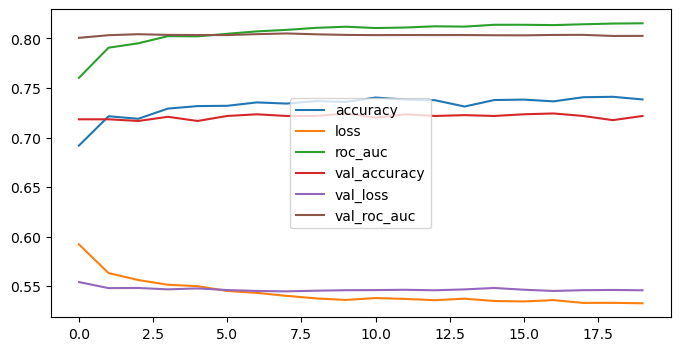

In [15]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,4))


In [17]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

test_probs = mlp_model.predict(X_test_scaled).flatten()
test_preds = (test_probs >= 0.5).astype(int)
print('Test Accuracy:', accuracy_score(y_test, test_preds))
print('Test F1:', f1_score(y_test, test_preds))
print('Test ROC-AUC:', roc_auc_score(y_test, test_probs))


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step
Test Accuracy: 0.7160931174089069
Test F1: 0.7115681233933162
Test ROC-AUC: 0.8059120617944147


## Engineered feature experiment (MLP)

In [24]:
eng_features = [col for col in engineered_df.columns if col != TARGET]
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    engineered_df[eng_features],
    engineered_df[TARGET],
    test_size=0.2,
    stratify=engineered_df[TARGET],
    random_state=42,
)
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)
mlp_eng = build_mlp(X_train_eng_scaled.shape[1])
mlp_eng_history = mlp_eng.fit(
    X_train_eng_scaled,
    y_train_eng,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    verbose=0,
)
mlp_eng_probs = mlp_eng.predict(X_test_eng_scaled).flatten()
mlp_eng_preds = (mlp_eng_probs >= 0.5).astype(int)
print('Engineered Accuracy:', accuracy_score(y_test_eng, mlp_eng_preds))
print('Engineered F1:', f1_score(y_test_eng, mlp_eng_preds))
print('Engineered ROC-AUC:', roc_auc_score(y_test_eng, mlp_eng_probs))


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step
Engineered Accuracy: 0.7171052631578947
Engineered F1: 0.7099117799688636
Engineered ROC-AUC: 0.8052379781588707


### Notes for the report
- Learning curves from the history plot show convergence (attach screenshot/figure).
- Compare metrics vs. logistic + decision forest to justify the added complexity.